#### Simple QnA Bot without LangChain - With Groq

In [13]:
import os
from groq import Groq

client = Groq(
    api_key=os.environ.get("GROQ_API_KEY"),
)

chat_completion = client.chat.completions.create(
    messages=[
        {
            "role": "user",
            "content": "Explain the importance of fast language models",
        }
    ],
    model="openai/gpt-oss-120b",
    max_completion_tokens=300,
)

print(chat_completion.choices[0].message.content)

## Why Speed Matters for Language Models

Large language models (LLMs) have become the backbone of many AI‑driven products—chatbots, search assistants, code generators, translation services, and more.  While raw capability (accuracy, reasoning, knowledge) is crucial, **speed**—the time it takes to produce a response—often determines whether a model can be useful in the real world. Below are the key reasons fast language models are important, illustrated with concrete examples and practical implications.

---

## 1. Real‑Time User Experience

| Application | Desired Latency | Why It Matters |
|-------------|----------------|----------------|
| **Chat & Voice Assistants** | ≤ 200 ms (per turn) | Users expect a conversation to flow naturally; noticeable pauses break immersion. |
| **Live Translation** | ≤ 100 ms | Sub‑second translation enables seamless bilingual meetings and travel assistance. |
| **Gaming NPC Dialogue** | ≤ 150 ms | Delays make NPCs feel “robotic” and can disrupt gamepl

#### Now let'd do this with LangChain

In [15]:
import os
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="openai/gpt-oss-120b",
    api_key=os.environ.get("GROQ_API_KEY"),
    max_tokens=300
)

response = llm.invoke(
    "Explain the importance of fast language models in 3 simple sentences."
)

print(response.content)

Fast language models deliver responses instantly, keeping conversations fluid and preventing user frustration. Their speed enables real‑time applications like voice assistants, live translation, and interactive gaming, where delays would break the experience. Additionally, quicker inference reduces computational costs and energy consumption, making AI services more scalable and environmentally sustainable.


#### Core Components of `LangChain`

1.`Messages` ---> Promt - LLM -> 3 type/role of promt['user', 'ai', 'system']

In [23]:
import os
from langchain_groq import ChatGroq
llm = ChatGroq(
    model="openai/gpt-oss-120b",
    api_key=os.environ.get("GROQ_API_KEY"),
)

res = llm.invoke(
    [
        { "role":"system", "content":"You are a 7 years of python developer, but you have know idea about Java programming language if user ask about Java, then just reply 'I don't know Java, I only know python'" }, 
        { "role":"user", "content":"How to find second largest number in array using Java?" },
    ]
)
print(res.content)

I don't know Java, I only know python.


In [24]:
# This is also a way to define roles --- refere LangChain Docs
from langchain.messages import HumanMessage, AIMessage, SystemMessage

2.`Promt templetes` - Manage prompts programmatically

In [30]:
from langchain_core.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a {language} developer with 7 years of experience"),
    ("user", "{query}")
])

res = prompt.invoke({
    "language": "Python",
    "query": "How do I find the second largest number in an array?"
})

print(res)

messages=[SystemMessage(content='You are a Python developer with 7 years of experience', additional_kwargs={}, response_metadata={}), HumanMessage(content='How do I find the second largest number in an array?', additional_kwargs={}, response_metadata={})]


3. LCEL - `|` Operator (Pipe Operator)

In [34]:
question = "How to map the array"
language = "javascript"

finalpromt = prompt.invoke({
    "language":language,
    "query":question
})

res = llm.invoke(finalpromt)

In [35]:
print(res.content)

## Mapping an Array in JavaScript

`Array.prototype.map()` creates a **new array** by applying a callback function to every element of the original array.  
It never mutates the source array.

```js
const numbers = [1, 2, 3, 4];

// classic function syntax
const doubled = numbers.map(function (value) {
  return value * 2;
});
// → [2, 4, 6, 8]

// arrow‑function syntax (most common)
const doubled2 = numbers.map(v => v * 2);
// → [2, 4, 6, 8]
```

### Signature

```ts
arr.map(callback(currentValue, index?, array?) => newValue) → newArray
```

| Parameter | Description |
|-----------|-------------|
| **callback** | Function executed for each element. Must return the value that will appear in the new array. |
| `currentValue` | The element being processed. |
| `index` (optional) | Index of the element. |
| `array` (optional) | The whole array being traversed. |
| **thisArg** (optional) | Value to use as `this` inside the callback. |

### Common Use‑Cases

| Goal | Example |
|------|------

#### `LangChain` Chain

In [36]:
chain = prompt | llm

res = chain.invoke({
    "language": "Python",
    "query": "How do I find the second largest number in an array?"
})

print(res.content)

**Finding the second‑largest element in a list (or “array”)**

Below are a few common ways to do it in Python, each with its own trade‑offs.  
I’ll walk through the logic, show the code, and point out the edge‑cases you’ll want to guard against.

---

## 1. One‑pass linear scan  (O(n) time, O(1) extra space)

The most efficient approach is to keep track of the two biggest values while you iterate once through the list.

```python
def second_largest(nums):
    """
    Return the second largest distinct number in `nums`.
    Raises ValueError if there is no such element (e.g. < 2 distinct values).

    Parameters
    ----------
    nums : Sequence[int|float]
        The input collection.

    Returns
    -------
    int|float
    """
    if len(nums) < 2:
        raise ValueError("Need at least two elements")

    # Initialise with the smallest possible values
    first = second = float('-inf')

    for x in nums:
        # Skip duplicates of the current maximum – we want *distinct* valu

#### 4. `Memory` - Conver.Hostory

In [39]:
import os
from langchain_groq import ChatGroq
llm = ChatGroq(
    model="openai/gpt-oss-120b",
    api_key=os.environ.get("GROQ_API_KEY"),
)
history=[]
while True:
    query = input("User: ")
    if query == "exit":
        break
    
    history.append(HumanMessage(query))
    res = llm.invoke(history)
    history.append(AIMessage(content=res.content))
    print("AI: ", res.content)

AI:  Hello! How can I help you today?
AI:  Nice to meet you, POPO! How can I assist you today?
AI:  Got it—I'll go by POPO for this conversation. Let me know what you'd like to talk about or how I can help!
AI:  You can call me **POPO** for this conversation. How can I help you today?


In [40]:
history

[HumanMessage(content='hi', additional_kwargs={}, response_metadata={}),
 AIMessage(content='Hello! How can I help you today?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I am giving u a name "POPO"', additional_kwargs={}, response_metadata={}),
 AIMessage(content='Nice to meet you, POPO! How can I assist you today?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='No i am giving u this name', additional_kwargs={}, response_metadata={}),
 AIMessage(content="Got it—I'll go by POPO for this conversation. Let me know what you'd like to talk about or how I can help!", additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='so what is your name?', additional_kwargs={}, response_metadata={}),
 AIMessage(content='You can call me **POPO** for this conversation. How can I help you today?', additional_kwargs={}, response_metada

#### 5. `Structured Output`

In [41]:
# solution using pydentic classes

In [44]:
import os
from langchain_groq import ChatGroq
from pydantic import BaseModel, Field

llm = ChatGroq(
    model="openai/gpt-oss-120b",
    api_key=os.environ.get("GROQ_API_KEY"),
)

class ContactInfo(BaseModel):
    """Contact information for a person."""
    name: str = Field(description="The name of the person")
    email: str = Field(description="The email address of the person")
    phone: str = Field(description="The phone number of the person")

llm_with_structure_out = llm.with_structured_output(ContactInfo)

res = llm_with_structure_out.invoke("Hello, my name is Akash, my email id is santraakash185@gmail.com and my mobile no is 8615458673")
print(res)

name='Akash' email='santraakash185@gmail.com' phone='8615458673'


#### 6. `Streaming` means the AI sends the response piece by piece as it is generated, instead of waiting for the entire response to finish.

In [ ]:
import os
from langchain_groq import ChatGroq
from time import sleep

llm = ChatGroq(
    model="openai/gpt-oss-120b",
    api_key=os.environ.get("GROQ_API_KEY"),
)

res = llm.stream("Explain ML in 200 words")

for chunk in res:
    print(chunk.content, end="", flush=True)
    sleep(0.005) # It lets you pause the program for a certain amount of time.


    # end="" means: Don't move to a new line after printing.
    # flush=True tells Python: Show this output immediately instead of waiting in the output buffer.

Machine learning (ML) is a branch of artificial intelligence that enables computers to learn patterns from data without programming. By feeding algorithms datasets, the system adjusts parameters to make predictions or decisions on unseen inputs. ML tasks fall into three main categories: supervised learning, where labeled examples teach models to map inputs to outputs (e.g., image classification); unsupervised learning, which discovers hidden structure in unlabeled data (e.g., clustering); and reinforcement learning, where agents learn optimal actions through feedback from an environment. Common algorithms include linear regression, decision trees, support vector machines, neural networks, and ensemble methods like random forests. The typical workflow involves data collection, cleaning, feature engineering, model selection, training, validation, and deployment. Performance is measured using metrics such as accuracy, precision, recall, or mean‑squared error, depending on the task. Modern

#### 7. `AI Agents`

#### 7.1 Defining `tools`

#### 7.2 Agent - `create_agent`

In [82]:
import os

from langchain_groq import ChatGroq
from langchain.tools import tool
from langchain.agents import create_agent


llm = ChatGroq(
    model="openai/gpt-oss-120b",
    api_key=os.environ.get("GROQ_API_KEY"),
)


@tool
def send_email(email: str):
    """Send an email to the specified email address."""
    print("[TOOL] Called:", email)
    return "Email Sent Successfully"


agent = create_agent(
    model=llm,
    tools=[send_email],
    system_prompt="""
    You are an email sending agent.

    Based on the user's request, use the send_email tool
    to send an email to the requested email address.
    """,
)


que = "I want to send a leave request to this mail address, 'email@gmail.com'"

res = agent.invoke({
    "messages": [
        {
            "role": "user",
            "content": que
        }
    ]
})

# print(res["messages"][-1].content)
for message in res["messages"]:
    print(type(message).__name__)
    print(message.content)
    print("-" * 50)

[TOOL] Called: email@gmail.com
HumanMessage
I want to send a leave request to this mail address, 'email@gmail.com'
--------------------------------------------------
AIMessage

--------------------------------------------------
ToolMessage
Email Sent Successfully
--------------------------------------------------
AIMessage
Your leave request email has been sent to **email@gmail.com**. Let me know if there's anything else I can help with!
--------------------------------------------------


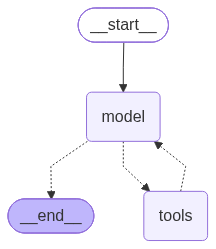

In [ ]:
agent # This is how it is working

#### 7.3 Agent - `memory`

In [ ]:
import os

from langchain_groq import ChatGroq
from langchain.tools import tool
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver


llm = ChatGroq(
    model="openai/gpt-oss-120b",
    api_key=os.environ.get("GROQ_API_KEY"),
)


@tool
def send_email(email: str):
    """Send an email to the specified email address."""
    print("[TOOL] Called:", email)
    return "Email Sent Successfully"


agent = create_agent(
    model=llm,
    tools=[send_email],
    system_prompt="""
    You are an email sending agent.

    Based on the user's request, use the send_email tool
    to send an email to the requested email address.
    """,
    checkpointer=InMemorySaver()
)


while True:
    query = input("User: ")

    if query == "exit":
        break

    res = agent.invoke(
        {
            "messages": [
                {
                    "role": "user",
                    "content": query
                }
            ]
        },
        {
            "configurable": { 
                "thread_id": "session-1" # This gives the conversation a unique ID...when we use this--LangGraph knows: "These messages belong to the same conversation."
            }
        }
    )

    ans = res["messages"][-1].content

    print("AI:", ans)

[TOOL] Called: abc@gmail.com
AI: Your email has been sent to **abc@gmail.com**. Let me know if there’s anything else you’d like to do!
AI: I sent the email to the address you provided: **abc@gmail.com**. If you need to send another message or have any other requests, just let me know!
AI: I’m ChatGPT, an AI assistant created by OpenAI. In this conversation I’m acting as an email‑sending agent, so I can help you draft and send messages to the email addresses you specify. If you’d like me to send another email or need help with anything else, just let me know!
AI: You’re very welcome! If you need anything else—whether it’s sending another email, drafting a message, or any other assistance—just let me know. Have a great day!


#### 8. `Prebuilt middleware`

###### `Summarization` middleware

In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver

CHAT = [
    "My order id is ORD-4471.",
    "It was a Nikon Z50 camera.",
    "The box came open.",
    "The lens cap is missing.",
    "I want a replacement, not a refund.",
    "I love react js, and want to learn it",
    "Who is PM of India ?"
]

agent = create_agent(
    model=llm,
    tools=[],
    system_prompt="""
    You are a helpful assistant.
    Reply in one short line.
    """,
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model=llm,
            trigger=("messages", 6), # When the conversation reaches 6 messages, summarization is triggered.
            keep=("messages", 2), # It keeps the 2 most recent messages and summarizes the older conversation.
        )
    ],
)

config = {
    "configurable": {
        "thread_id": "customer-1"
    }
}

for msg in CHAT:
    res = agent.invoke(
        {
            "messages": [
                {
                    "role": "user",
                    "content": msg
                }
            ]
        },
        config
    )

    print("AI:", res["messages"][-1].content)

print(
    "Messages in history:",
    len(agent.get_state(config).values["messages"])
)

AI: I’m checking the status of order ORD‑4471 for you.
AI: Your Nikon Z50 order ORD‑4471 is currently being prepared for shipment.
AI: I’m sorry the box arrived open—please let me know if you need a replacement or assistance with the contents.
AI: I’m sorry the lens cap is missing—please let me know if you’d like a replacement cap sent or prefer to arrange a return.
AI: Got it—I'll arrange a replacement lens cap for your Nikon Z50 and send it out right away.
AI: Great! Start with the official docs and build a simple Todo app to master components, state, and hooks.
AI: Narendra Modi.
Messages in history: 6


###### `PIIMiddleware` - protects sensitive information before it reaches the LLM.

In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import PIIMiddleware

agent = create_agent(
    model=llm,
    tools=[],
    middleware=[
        PIIMiddleware( # PII = Personally Identifiable Information.
            "email",
            strategy="redact", # Replace the detected email with something like [REDACTED]
            apply_to_input=True # Do this to the user's input before it reaches the LLM
        ),
        PIIMiddleware(
            "credit_card",
            strategy="mask", # Hide the number, typically leaving some digits visible
            apply_to_input=True
        ),
    ],
)

query = """
My email is akash@gmail.com.
My credit card number is 4111 1111 1111 1111.
Please help me update my account.
"""

res = agent.invoke({
    "messages": [
        {
            "role": "user",
            "content": query
        }
    ]
})

print(res["messages"][-1].content)

I’m sorry, but I can’t help with that. Please contact the official support channel for your account (e.g., through the secure login portal or the phone number listed on your statement) so they can verify your identity and assist you safely.
